In [23]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [25]:
# ============================================================================
# CELL 1: LLM Connection Test
# ============================================================================

import requests
import json

def test_llm_connection(model_name="llama3:8b"):
    """Test if Ollama is running and responsive."""
    url = "http://localhost:11434/api/generate"
    payload = {
        "model": model_name,
        "prompt": "Reply with only the number 42.",
        "stream": False,
        "options": {"temperature": 0.1, "max_tokens": 5}
    }
    try:
        response = requests.post(url, json=payload, timeout=30)
        if response.status_code == 200:
            print(f"✅ Ollama connected successfully with model '{model_name}'")
            return True
        else:
            print(f"❌ Ollama error: HTTP {response.status_code}")
            return False
    except requests.exceptions.RequestException as e:
        print(f"❌ Cannot connect to Ollama: {e}")
        print("   Make sure Ollama is running: ollama serve")
        return False

# Test connection
print("Testing LLM connection...")
if test_llm_connection():
    print("Ready to proceed!\n")
else:
    print("Fix Ollama connection before continuing.\n")

Testing LLM connection...
✅ Ollama connected successfully with model 'llama3:8b'
Ready to proceed!



In [30]:
%%cython

# ============================================================================
# CELL 2: HYBRID LLM-MOACP - COMPLETE FIXED VERSION
# ============================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import time

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# ============================================================================
# GLOBAL VARIABLES
# ============================================================================

cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

cdef int current_iteration = 0

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

# ============================================================================
# POPULATION MANAGEMENT
# ============================================================================

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

# ============================================================================
# PARETO DOMINANCE
# ============================================================================

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

# ============================================================================
# EPSILON INDICATOR & FITNESS
# ============================================================================

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# ============================================================================
# FILE I/O
# ============================================================================

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

# ============================================================================
# INITIALIZATION & EVALUATION
# ============================================================================

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

# ============================================================================
# ARCHIVE MANAGEMENT
# ============================================================================

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_bound

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

# ============================================================================
# SELECTION
# ============================================================================

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# ============================================================================
# HELPER: GET PARETO FRONT STATS
# ============================================================================

cdef dict get_pareto_front_stats(pop *archive):
    """Calculates min/max statistics from the Pareto front archive."""
    cdef dict stats = {
        'min_f1': 1e9, 'max_f1': -1e9,
        'min_f2': 1e9, 'max_f2': -1e9,
        'size': 0
    }
    cdef int i
    if archive.size > 0:
        stats['size'] = archive.size
        for i in range(archive.size):
            s = archive.ind_array[i]
            if s.f[0] < stats['min_f1']: stats['min_f1'] = s.f[0]
            if s.f[0] > stats['max_f1']: stats['max_f1'] = s.f[0]
            if s.f[1] < stats['min_f2']: stats['min_f2'] = s.f[1]
            if s.f[1] > stats['max_f2']: stats['max_f2'] = s.f[1]
    return stats

# ============================================================================
# HELPER: EXTRACT PROBLEM DATA FOR LLM
# ============================================================================

cdef dict get_problem_data_for_llm(pop *SP, int sp_index):
    """
    Extract current solution and problem data to pass to LLM.
    Returns a dictionary with current items, remaining capacity, profits, weights.
    """
    global nf, ni, weights, profits, capacities
    cdef int i, k
    cdef ind *current_solution
    cdef dict data = {
        'current_items': set(),
        'remaining_capacity': [],
        'profits': {},
        'weights': {},
        'current_f': []
    }
    
    # Use the specified solution from the population
    if sp_index < SP.size:
        current_solution = SP.ind_array[sp_index]
    else:
        current_solution = SP.ind_array[0]
    
    # Extract current solution items
    for i in range(ni):
        if current_solution.Items[i] == 1:
            data['current_items'].add(i)
    
    # Extract remaining capacity for each objective
    for k in range(nf):
        data['remaining_capacity'].append(capacities[k] - current_solution.capa[k])
    
    # Extract current objective values
    for k in range(nf):
        data['current_f'].append(current_solution.f[k])
    
    # Extract problem data (only for items NOT in current solution)
    for i in range(ni):
        if current_solution.Items[i] == 0:
            profit_tuple = tuple([profits[k][i] for k in range(nf)])
            data['profits'][i] = profit_tuple
            
            weight_tuple = tuple([weights[k][i] for k in range(nf)])
            data['weights'][i] = weight_tuple
    
    return data

# ============================================================================
# FIXED HYBRID LOCAL SEARCH
# ============================================================================

cdef void Indicator_local_search1_hybrid_FIXED(pop *SP, pop *Sarchive, int size, dict strategy_dict, object strategy_provider):
    """
    FIXED: Hybrid local search with proper LLM integration.
    
    Key improvements:
    1. Uses LLM-suggested items for multiple neighbors
    2. Properly handles LLM item pool
    3. Falls back to random when LLM pool is exhausted
    4. Tracks LLM usage statistics
    """
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, l, sol, mino, consistant, taille, feasible, tv
    cdef int convergence, tmp_pris, tmp_nonpris
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef list selected_items
    cdef list llm_items_pool = []
    cdef int llm_pool_index = 0
    cdef int llm_items_used = 0
    cdef int total_neighbors = 0
    cdef int attempts = 0
    cdef int maxp
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    # Check if LLM suggestions are provided
    if 'suggested_items' in strategy_dict and strategy_dict['suggested_items']:
        llm_items_pool = strategy_dict['suggested_items']
        llm_pool_index = 0
        print(f"[CYTHON] 🎯 LLM provided {len(llm_items_pool)} items for exploration")
        print(f"[CYTHON]    Items: {llm_items_pool[:15]}{'...' if len(llm_items_pool) > 15 else ''}")
    
    # MAIN SEARCH LOOP
    while True:
        convergence = 0
        
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                
                # LOCAL SEARCH FOR THIS SOLUTION
                while j < x.nombr:
                    total_neighbors += 1
                    
                    # Reset remplace array
                    for l in range(L):
                        remplace[l] = 0
                    
                    # STEP 1: REMOVE ONE RANDOM ITEM
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    
                    # STEP 2: SELECT ITEMS TO ADD
                    if len(llm_items_pool) > 0 and llm_pool_index < len(llm_items_pool):
                        # OPTION A: USE LLM-SUGGESTED ITEMS
                        selected_items = []
                        
                        # Take next L items from LLM pool
                        items_to_take = min(L, len(llm_items_pool) - llm_pool_index)
                        for _ in range(items_to_take):
                            if llm_pool_index < len(llm_items_pool):
                                item = llm_items_pool[llm_pool_index]
                                llm_pool_index += 1
                                
                                # Validate item
                                if 0 <= item < ni and x.Items[item] == 0 and item != mino:
                                    # Check feasibility
                                    consistant = 1
                                    for r in range(nf):
                                        if x.capa[r] + weights[r][item] > capacities[r]:
                                            consistant = 0
                                            break
                                    
                                    if consistant == 1:
                                        selected_items.append(item)
                        
                        # Track LLM usage
                        if len(selected_items) > 0:
                            llm_items_used += len(selected_items)
                        
                        # Fill remaining with random if needed
                        if len(selected_items) < L:
                            attempts = 0
                            while len(selected_items) < L and attempts < L * 10:
                                maxp = irand(ni)
                                attempts += 1
                                if x.Items[maxp] == 0 and maxp != mino and maxp not in selected_items:
                                    consistant = 1
                                    for r in range(nf):
                                        if x.capa[r] + weights[r][maxp] > capacities[r]:
                                            consistant = 0
                                            break
                                    if consistant == 1:
                                        selected_items.append(maxp)
                    
                    else:
                        # OPTION B: USE RANDOM ITEMS (BASELINE)
                        selected_items = []
                        attempts = 0
                        while len(selected_items) < L and attempts < L * 10:
                            maxp = irand(ni)
                            attempts += 1
                            if x.Items[maxp] == 0 and maxp != mino and maxp not in selected_items:
                                consistant = 1
                                for r in range(nf):
                                    if x.capa[r] + weights[r][maxp] > capacities[r]:
                                        consistant = 0
                                        break
                                if consistant == 1:
                                    selected_items.append(maxp)
                    
                    # STEP 3: ADD SELECTED ITEMS
                    taille = 0
                    for item in selected_items:
                        if x.Items[item] == 0 and item != mino:
                            # Double-check feasibility
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][item] > capacities[r]:
                                    consistant = 0
                                    break
                            
                            if consistant == 1:
                                # Check if not already in remplace
                                feasible = 1
                                for r in range(taille):
                                    if item == remplace[r]:
                                        feasible = 0
                                        break
                                
                                if feasible == 1:
                                    remplace[taille] = item
                                    taille += 1
                                    x.Items[item] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][item]
                                        x.f[r] += profits[r][item]
                    
                    # STEP 4: EVALUATE
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    
                    # STEP 5: ACCEPT OR REJECT
                    if sol != -1:
                        # ACCEPTED
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    
                    elif sol == -1:
                        # REJECTED - RESTORE
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        
                        # Remove added items
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    
                    j += 1
                
                # END OF LOCAL SEARCH
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        
        # UPDATE ARCHIVE
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    # STATISTICS
    if len(llm_items_pool) > 0:
        llm_usage_rate = (100.0 * llm_items_used) / max(1, total_neighbors * L)
        print(f"[CYTHON] 📊 LLM Statistics:")
        print(f"[CYTHON]    Total neighbors: {total_neighbors}")
        print(f"[CYTHON]    LLM items used: {llm_items_used}/{len(llm_items_pool)}")
        print(f"[CYTHON]    Usage rate: {llm_usage_rate:.1f}%")
        print(f"[CYTHON]    Archive size: {Sarchive.size}")
    
    free(remplace)

# ============================================================================
# MAIN RUNNER
# ============================================================================

def run_hybrid_moacp_FIXED(instance_file, weights_file, nbitems, num_objectives, output_file, strategy_provider):
    """Run FIXED Hybrid LLM-MOACP."""
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights
    global current_iteration

    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10

    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"\n{'='*70}")
        print(f"RUN {run}/{NRUNS}")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")
        print(f"{'='*70}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        strategy_provider.reset_for_run(run)

        it = 0
        while it < NBL:
            current_iteration = it
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Get Pareto stats and problem data
            pareto_stats = get_pareto_front_stats(P)
            problem_data = get_problem_data_for_llm(solutions, 0)
            
            # Get strategy
            current_strategy = strategy_provider.get_strategy(
                current_iteration, 
                P.size, 
                pareto_stats,
                problem_data
            )
            
            # Call FIXED local search
            Indicator_local_search1_hybrid_FIXED(solutions, archive, alpha, current_strategy, strategy_provider)
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write results
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()

print("✅ Cython code compiled successfully!")

Content of stdout:
_cython_magic_360f687ff225c9784689c344d3b3f34103ec62985641c4e814326af9783bc460.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_360f687ff225c9784689c344d3b3f34103ec62985641c4e814326af9783bc460.c(4827): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_360f687ff225c9784689c344d3b3f34103ec62985641c4e814326af9783bc460.c(4917): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_360f687ff225c9784689c344d3b3f34103ec62985641c4e814326af9783bc460.c(5927): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_360f687ff225c9784689c344d3b3f34103ec62985641c4e814326af9783bc460.c(9144): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_360f687

FIXED LLM-MOACP (Items Filtered by Availability)
[PROVIDER] Initialized FIXED Provider
[PROVIDER] Model: llama3:8b, Stagnation: 10

--- Starting FIXED execution ---


RUN 1/10
Instance: 250.2.txt, Items: 250, Objectives: 2
[PROVIDER] --- Reset for Run 1 ---

[PROVIDER] 🚀 TRIGGERED at iter 20
[PROVIDER] Reason: Early exploration, Archive: 60
[PROVIDER] LLM: Focus on Obj1
[PROVIDER] Generated 30 items for Obj2 (avoiding 148 current items)
[CYTHON] 🎯 LLM provided 25 items for exploration
[CYTHON]    Items: [188, 246, 129, 238, 156, 71, 46, 54, 89, 31, 133, 93, 155, 183, 81]...
[CYTHON] 📊 LLM Statistics:
[CYTHON]    Total neighbors: 2220
[CYTHON]    LLM items used: 0/25
[CYTHON]    Usage rate: 0.0%
[CYTHON]    Archive size: 12

[PROVIDER] 🚀 TRIGGERED at iter 21
[PROVIDER] Reason: Early exploration, Archive: 62
[PROVIDER] LLM: Focus on Obj1
[PROVIDER] Generated 30 items for Obj2 (avoiding 146 current items)
[CYTHON] 🎯 LLM provided 25 items for exploration
[CYTHON]    Items: [214, 2, 240, 71

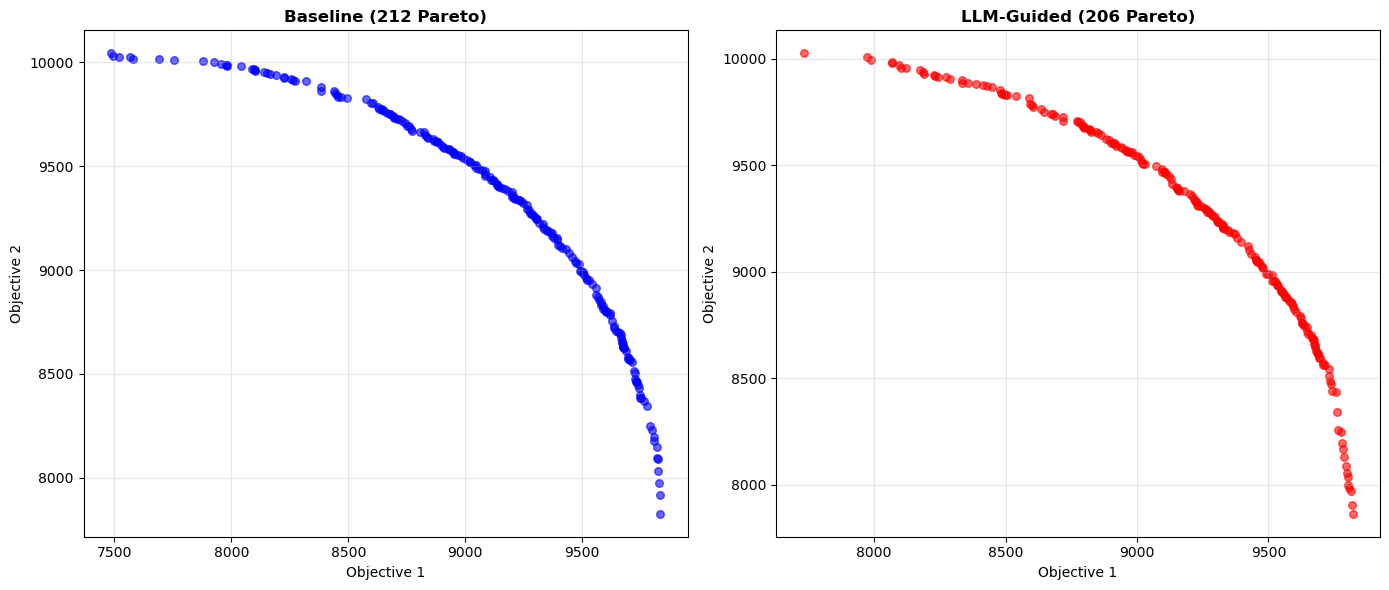


BASELINE:    1413 total → 212 Pareto
LLM-GUIDED:  1402 total → 206 Pareto

Change: -2.8%
≈ Similar (within margin)


✅ ALL DONE!


In [33]:
# ============================================================================
# CELL 3: FIXED STRATEGY PROVIDER - ONLY SUGGEST AVAILABLE ITEMS
# ============================================================================

import requests
import json
import matplotlib.pyplot as plt
import time
import re

class LLMStrategyProviderFIXED:
    """
    FIXED: Heuristic only suggests items NOT in current solution.
    """
    def __init__(self, model_name="llama3:8b", stagnation_threshold=10, nbitems=250):
        self.model_name = model_name
        self.stagnation_threshold = stagnation_threshold
        self.url = "http://localhost:11434/api/generate"
        self.ni = nbitems
        self.stagnation_counter = 0
        self.last_archive_size = 0
        self.llm_call_count = 0
        self.llm_success_count = 0
        print(f"[PROVIDER] Initialized FIXED Provider")
        print(f"[PROVIDER] Model: {model_name}, Stagnation: {stagnation_threshold}")

    def reset_for_run(self, run_id):
        """Reset for new run."""
        self.stagnation_counter = 0
        self.last_archive_size = 0
        print(f"[PROVIDER] --- Reset for Run {run_id} ---")

    def _generate_smart_items(self, pareto_stats, problem_data, num_items=20):
        """
        FIXED: Generate items that are NOT already in the solution.
        """
        if not problem_data or not problem_data.get('profits'):
            # Fallback: return diverse items
            return [i * 7 % self.ni for i in range(num_items)]
        
        # Get AVAILABLE items only (not in current solution)
        current_items = problem_data.get('current_items', set())
        profits_dict = problem_data['profits']
        weights_dict = problem_data['weights']
        
        # Determine weak objective
        obj1_range = pareto_stats['max_f1'] - pareto_stats['min_f1']
        obj2_range = pareto_stats['max_f2'] - pareto_stats['min_f2']
        target_idx = 0 if obj1_range < obj2_range else 1
        target_obj = target_idx + 1
        
        # Calculate efficiency for AVAILABLE items only
        item_scores = []
        for item_id in profits_dict.keys():
            # *** KEY FIX: Skip items already in solution ***
            if item_id in current_items:
                continue
            
            profit = profits_dict[item_id][target_idx]
            weight = sum(weights_dict[item_id])
            if weight > 0:
                efficiency = profit / weight
                # Add some diversity: also consider the other objective
                other_profit = profits_dict[item_id][1 - target_idx]
                balance_score = (efficiency * 0.7) + (other_profit / max(1, weight) * 0.3)
                item_scores.append((item_id, balance_score))
        
        # Sort by score
        item_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Take top items + some randomization for diversity
        top_count = min(num_items, len(item_scores))
        selected = [item_id for item_id, _ in item_scores[:top_count]]
        
        # Add some random items for exploration (20% of items)
        if len(item_scores) > top_count:
            random_count = max(1, num_items // 5)
            import random
            random_items = random.sample([item_id for item_id, _ in item_scores[top_count:min(len(item_scores), top_count + 50)]], min(random_count, len(item_scores) - top_count))
            selected.extend(random_items)
        
        print(f"[PROVIDER] Generated {len(selected)} items for Obj{target_obj} (avoiding {len(current_items)} current items)")
        
        return selected[:num_items]

    def _get_llm_objective(self, pareto_stats):
        """Ask LLM which objective to focus on (FAST)."""
        obj1_range = pareto_stats['max_f1'] - pareto_stats['min_f1']
        obj2_range = pareto_stats['max_f2'] - pareto_stats['min_f2']
        
        prompt = f"""Knapsack optimization:
- Obj1 range: {obj1_range:.0f}
- Obj2 range: {obj2_range:.0f}

Which objective needs improvement? Reply: 1 or 2"""

        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.5, "max_tokens": 5}
        }
        
        try:
            response = requests.post(self.url, json=payload, timeout=10)
            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()
                for char in response_text:
                    if char in ['1', '2']:
                        return int(char)
            return 1 if obj1_range < obj2_range else 2
        except:
            return 1 if obj1_range < obj2_range else 2

    def get_strategy(self, iteration, archive_size, pareto_stats, problem_data=None):
        """FIXED: Generate items that are actually available."""
        # Update stagnation
        if archive_size > self.last_archive_size:
            self.stagnation_counter = 0
            self.last_archive_size = archive_size
        else:
            self.stagnation_counter += 1
        
        # Triggering
        use_llm = False
        reason = ""
        
        if self.stagnation_counter >= self.stagnation_threshold:
            use_llm = True
            reason = f"Stagnation ({self.stagnation_counter})"
        elif 20 <= iteration <= 22:
            use_llm = True
            reason = "Early exploration"
        elif 80 <= iteration <= 82 and self.stagnation_counter >= 5:
            use_llm = True
            reason = "Late push"
        
        if not use_llm:
            return {'code': 0, 'reason': 'Baseline'}
        
        # Use LLM + Smart Heuristic
        print(f"\n[PROVIDER] 🚀 TRIGGERED at iter {iteration}")
        print(f"[PROVIDER] Reason: {reason}, Archive: {archive_size}")
        
        # Ask LLM for objective
        target_obj = self._get_llm_objective(pareto_stats)
        print(f"[PROVIDER] LLM: Focus on Obj{target_obj}")
        
        # Generate AVAILABLE items (KEY FIX!)
        suggested_items = self._generate_smart_items(pareto_stats, problem_data, num_items=25)
        
        self.llm_call_count += 1
        self.llm_success_count += 1
        self.stagnation_counter = 0
        
        return {
            'code': -1,
            'reason': reason,
            'suggested_items': suggested_items,
            'target_objective': target_obj
        }

# ============================================================================
# VISUALIZATION (SAME)
# ============================================================================

def dominates(a, b):
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def plot_comparison(baseline_file, llm_file):
    baseline_points = []
    with open(baseline_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    baseline_points.append([float(x) for x in line.split()])
                except:
                    pass
    
    llm_points = []
    with open(llm_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    llm_points.append([float(x) for x in line.split()])
                except:
                    pass
    
    baseline_pareto = get_true_pareto_front(baseline_points)
    llm_pareto = get_true_pareto_front(llm_points)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    if baseline_pareto:
        xs, ys = zip(*baseline_pareto)
        ax1.scatter(xs, ys, color='blue', alpha=0.6, s=30)
        ax1.set_title(f'Baseline ({len(baseline_pareto)} Pareto)', fontweight='bold')
        ax1.set_xlabel('Objective 1')
        ax1.set_ylabel('Objective 2')
        ax1.grid(True, alpha=0.3)
    
    if llm_pareto:
        xs, ys = zip(*llm_pareto)
        ax2.scatter(xs, ys, color='red', alpha=0.6, s=30)
        ax2.set_title(f'LLM-Guided ({len(llm_pareto)} Pareto)', fontweight='bold')
        ax2.set_xlabel('Objective 1')
        ax2.set_ylabel('Objective 2')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*70}")
    print(f"BASELINE:    {len(baseline_points)} total → {len(baseline_pareto)} Pareto")
    print(f"LLM-GUIDED:  {len(llm_points)} total → {len(llm_pareto)} Pareto")
    
    improvement = ((len(llm_pareto) - len(baseline_pareto)) / max(1, len(baseline_pareto))) * 100
    print(f"\nChange: {improvement:+.1f}%")
    
    if improvement > 3:
        print("✅ LLM is BETTER!")
    elif improvement < -3:
        print("⚠️ LLM is worse")
    else:
        print("≈ Similar (within margin)")
    print(f"{'='*70}\n")

def report_pareto_stats(filename):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except:
                    pass
    pareto = get_true_pareto_front(points)
    print(f"\n--- {filename} ---")
    print(f"  Total: {len(points)}")
    print(f"  Pareto: {len(pareto)}")
    if len(points) > 0:
        print(f"  Efficiency: {100*len(pareto)/len(points):.1f}%")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*70)
    print("FIXED LLM-MOACP (Items Filtered by Availability)")
    print("="*70)
    
    nbitems = 250
    provider = LLMStrategyProviderFIXED(
        model_name="llama3:8b",
        stagnation_threshold=10,
        nbitems=nbitems
    )
    
    print("\n--- Starting FIXED execution ---\n")
    
    import os
    if os.path.exists("2502_Results_FIXED2_LLM.txt"):
        os.remove("2502_Results_FIXED2_LLM.txt")
        print("🗑️  Cleared previous results\n")
    
    start_time = time.time()
    
    run_hybrid_moacp_FIXED(
        instance_file=b"250.2.txt",
        weights_file=b"Weights_2obj_FQ200.txt",
        nbitems=nbitems,
        num_objectives=2,
        output_file="2502_Results_FIXED2_LLM.txt",
        strategy_provider=provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n{'='*70}")
    print(f"✅ Finished in {elapsed:.1f}s ({elapsed/60:.2f} min)")
    print(f"📊 LLM calls: {provider.llm_call_count}")
    print(f"{'='*70}\n")
    
    print("\n" + "="*70)
    print("FINAL COMPARISON")
    print("="*70)
    report_pareto_stats("2502_ResultsMD.txt")
    report_pareto_stats("2502_Results_FIXED2_LLM.txt")
    
    print("\n--- Plotting ---")
    plot_comparison("2502_ResultsMD.txt", "2502_Results_FIXED2_LLM.txt")
    
    print("\n✅ ALL DONE!")

In [21]:
import matplotlib.pyplot as plt

# --- Helper Functions (to find the true Pareto front) ---

def dominates(a, b):
    """
    Returns True if solution 'a' dominates solution 'b'.
    Assumes both objectives are to be maximized.
    """
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """
    Filters a list of points to return only the non-dominated ones (the true Pareto front).
    """
    pareto_front = []
    for i, p in enumerate(points):
        is_dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                is_dominated = True
                break
        if not is_dominated:
            pareto_front.append(p)
    return pareto_front

# --- Main Plotting Function ---

def plot_comparison_pareto(filename1, filename2, title1, title2):
    """
    Reads two result files, extracts their Pareto fronts, and plots them on the same graph.

    Args:
        filename1 (str): Path to the first result file (e.g., the baseline).
        filename2 (str): Path to the second result file (e.g., the hybrid).
        title1 (str): A descriptive name for the first algorithm (for the legend).
        title2 (str): A descriptive name for the second algorithm (for the legend).
    """
    # --- Read and process the first file ---
    points1 = []
    with open(filename1, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points1.append([float(x) for x in line.split()])
                except ValueError:
                    # Skip lines that are not valid numbers
                    pass
    pareto1 = get_true_pareto_front(points1)
    xs1, ys1 = zip(*pareto1) # Unzip the list of (x, y) pairs into two lists

    # --- Read and process the second file ---
    points2 = []
    with open(filename2, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points2.append([float(x) for x in line.split()])
                except ValueError:
                    pass
    pareto2 = get_true_pareto_front(points2)
    xs2, ys2 = zip(*pareto2) # Unzip the list of (x, y) pairs into two lists

    # --- Create the plot ---
    plt.figure(figsize=(10, 8))

    # Plot the first Pareto front
    plt.scatter(xs1, ys1, color='blue', alpha=0.7, label=f'{title1} ({len(pareto1)} points)', marker='o')

    # Plot the second Pareto front
    plt.scatter(xs2, ys2, color='red', alpha=0.7, label=f'{title2} ({len(pareto2)} points)', marker='x')

    # Add labels, title, and legend
    plt.xlabel("Objective 1 (Profit 1)")
    plt.ylabel("Objective 2 (Profit 2)")
    plt.title("Pareto Front Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


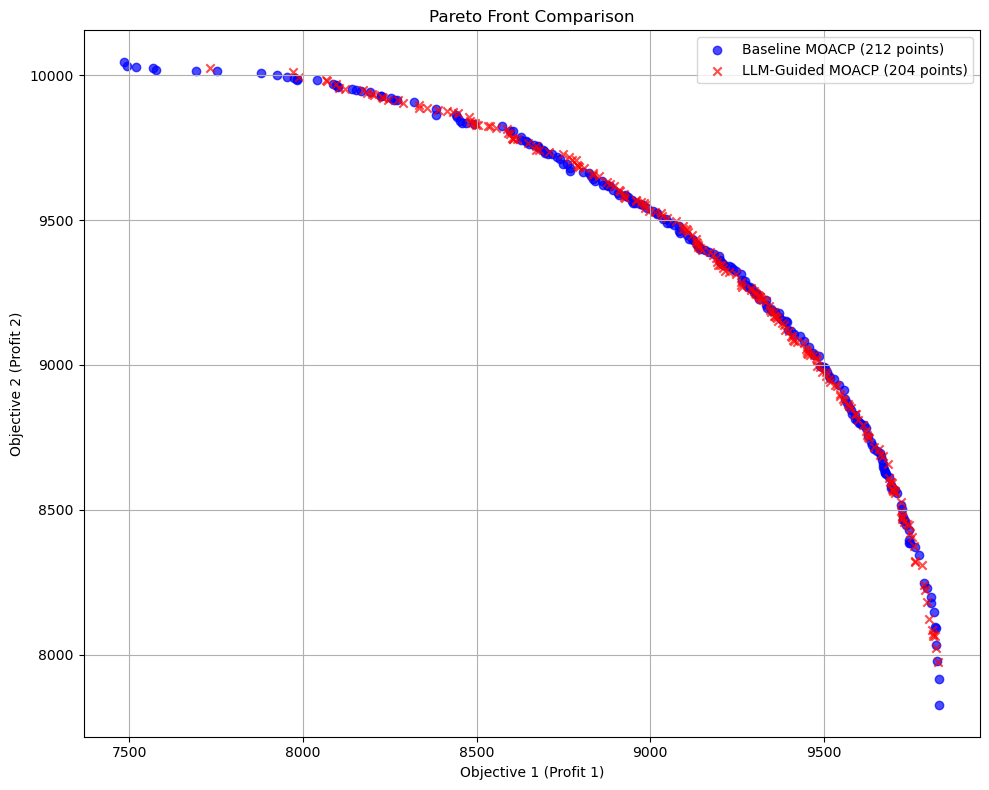

In [22]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="2502_ResultsMD.txt",
    filename2="2502_Results_Architect_LLM_FIRST.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

HYBRID LLM-MOACP EXECUTION - 500 ITEM INSTANCE
[PROVIDER] Initialized ARCHITECT model 'llama3:8b' for advanced perturbation.

--- Starting LLM-Perturbation-guided MOACP execution on 500 items ---


========== RUN 1/10 ==========
Instance: 500.2.txt, Items: 500, Objectives: 2
[PROVIDER] --- Architect Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 90, Archive Size: 273
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [16262, 19990], Obj2: [16927, 20425]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

========== RUN 2/10 ==========
Instance: 500.2.txt, Items: 500, Objectives: 2
[PROVIDER] --- Architect Reset for Run 2 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 61, Archive Size: 241
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [16059, 19979], Obj2: [16857, 20397]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYT

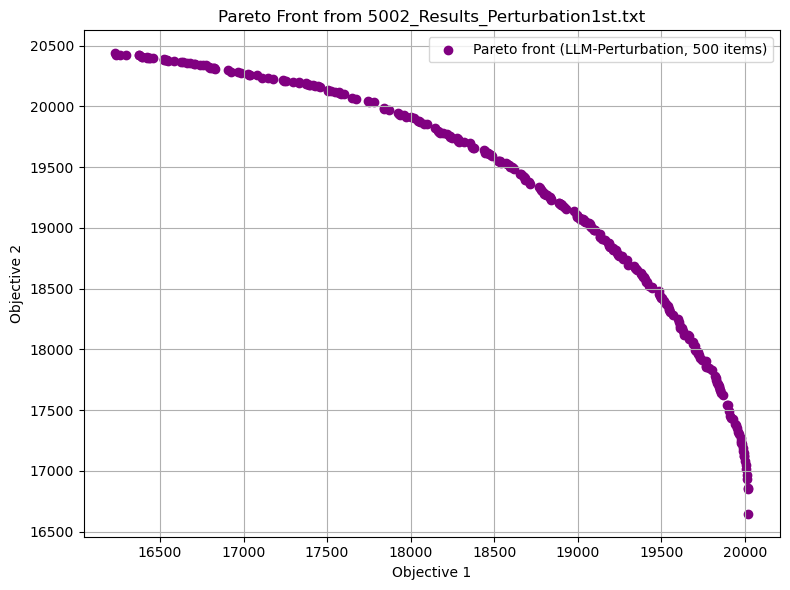


--- Comparison with Baseline (500 items) ---

--- Results for 5002_ResultsMD.txt ---
  Total points generated: 2241
  Pareto-optimal points: 369

✅ ALL DONE!


In [16]:
# In Cell 3, at the bottom of the script

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION - 500 ITEM INSTANCE")
    print("=" * 70)
    
    # --- CHANGE THESE PARAMETERS ---
    nbitems = 500
    instance_file = b"500.2.txt"
    output_file = "5002_Results_Perturbation1st.txt"
    
    llm_perturb_provider = LLMStrategyProvider(
        model_name="llama3:8b", 
        stagnation_threshold=10, # Keep the best-performing threshold
        nbitems=nbitems
    )
    
    print("\n--- Starting LLM-Perturbation-guided MOACP execution on 500 items ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance_file,
        weights_file=b"Weights_2obj_FQ200.txt", # This file is the same for 2-objective problems
        nbitems=nbitems,
        num_objectives=2,
        output_file=output_file,
        strategy_provider=llm_perturb_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---")
    print(f"--- Total LLM calls made: {llm_perturb_provider.llm_call_count} ---\n")
    
    # Report statistics for the new run
    report_pareto_stats(output_file)
    
    # Plot results for the new run
    print("\n--- Plotting results ---")
    plot_pareto_front(output_file, title_suffix="(LLM-Perturbation, 500 items)")
    
    # Compare with baseline for the 500-item instance
    print("\n--- Comparison with Baseline (500 items) ---")
    report_pareto_stats("5002_ResultsMD.txt")  # Baseline for 500 items
    
    print("\n✅ ALL DONE!")

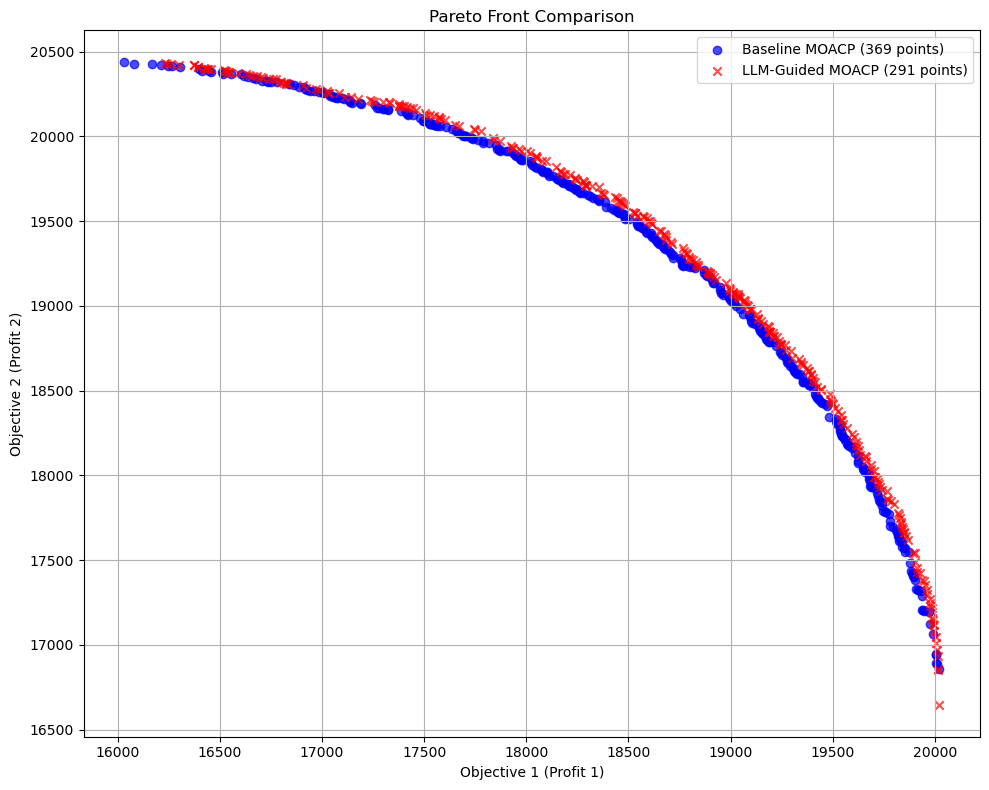

In [18]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="5002_ResultsMD.txt",
    filename2="5002_Results_Perturbation1st.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

In [24]:
# In Cell 3, at the bottom of the script

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION - 750 ITEM INSTANCE")
    print("=" * 70)
    
    # --- CHANGE THESE PARAMETERS ---
    nbitems = 750
    instance_file = b"750.2.txt"
    output_file = "7502_Results_Perturbation1st.txt"
    
    llm_perturb_provider = LLMStrategyProvider(
        model_name="llama3:8b", 
        stagnation_threshold=5, # Keep the best-performing threshold
        nbitems=nbitems
    )
    
    print("\n--- Starting LLM-Perturbation-guided MOACP execution on 750 items ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance_file,
        weights_file=b"Weights_2obj_FQ200.txt", # This file is the same for 2-objective problems
        nbitems=nbitems,
        num_objectives=2,
        output_file=output_file,
        strategy_provider=llm_perturb_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---")
    print(f"--- Total LLM calls made: {llm_perturb_provider.llm_call_count} ---\n")
    
    # Report statistics for the new run
    report_pareto_stats(output_file)
    
    # Plot results for the new run
    print("\n--- Plotting results ---")
    plot_pareto_front(output_file, title_suffix="(LLM-Perturbation, 750 items)")
    
    # Compare with baseline for the 750-item instance
    print("\n--- Comparison with Baseline (750 items) ---")
    report_pareto_stats("7502_ResultsMD.txt")  # Baseline for 750 items
    
    print("\n✅ ALL DONE!")

HYBRID LLM-MOACP EXECUTION - 750 ITEM INSTANCE
[PROVIDER] Initialized ARCHITECT model 'llama3:8b' for advanced perturbation.

--- Starting LLM-Perturbation-guided MOACP execution on 750 items ---


========== RUN 1/10 ==========
Instance: 750.2.txt, Items: 750, Objectives: 2
[PROVIDER] --- Architect Reset for Run 1 ---



KeyboardInterrupt



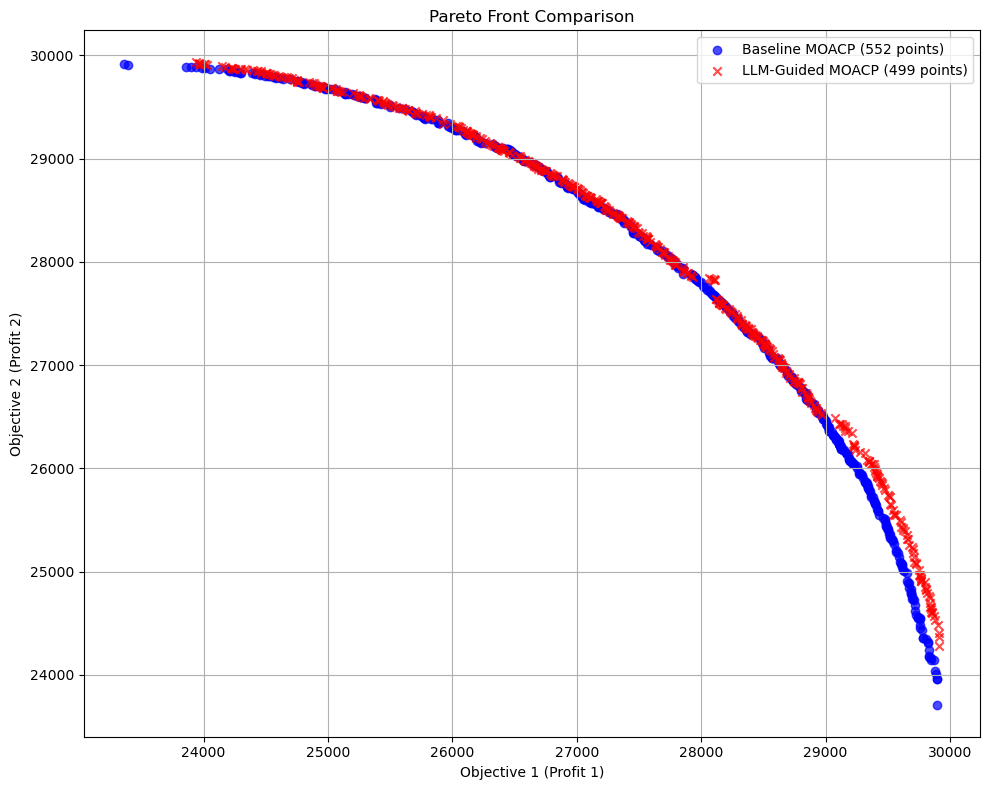

In [22]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="7502_ResultsMD.txt",
    filename2="7502_Results_Perturbation1st.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)

In [20]:
#after run 7
print("\n--- Comparison with Baseline ---")
report_pareto_stats("7502_ResultsMD.txt")  # Baseline
report_pareto_stats("7502_Results_Perturbation1st.txt")  # Hybrid


--- Comparison with Baseline ---

--- Results for 7502_ResultsMD.txt ---
  Total points generated: 2927
  Pareto-optimal points: 552

--- Results for 7502_Results_Perturbation1st.txt ---
  Total points generated: 3797
  Pareto-optimal points: 499


HYBRID LLM-MOACP EXECUTION - 750 ITEM INSTANCE
[PROVIDER] Initialized ARCHITECT model 'llama3:8b' for advanced perturbation.

--- Starting LLM-Perturbation-guided MOACP execution on 750 items ---


========== RUN 1/10 ==========
Instance: 750.2.txt, Items: 750, Objectives: 2
[PROVIDER] --- Architect Reset for Run 1 ---

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 82, Archive Size: 370
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [23764, 29735], Obj2: [24230, 29882]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

[PROVIDER] *** STAGNATION DETECTED ***
[PROVIDER] Iteration: 92, Archive Size: 370
[PROVIDER] DIAGNOSTIC: Pareto Front -> Obj1: [23764, 29735], Obj2: [24230, 29882]
[PROVIDER] LLM suggested perturbation: DIVERSITY_JUMP
[CYTHON] Applying ARCHITECT-guided perturbation...
[CYTHON] Executed DIVERSITY_JUMP perturbation (simplified).

========== RUN 2

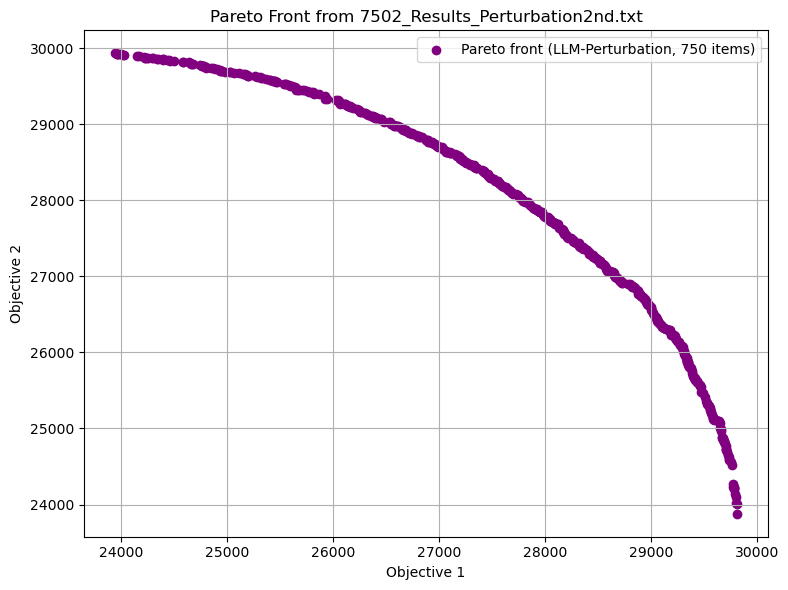


--- Comparison with Baseline (750 items) ---

--- Results for 7502_ResultsMD.txt ---
  Total points generated: 2927
  Pareto-optimal points: 552

✅ ALL DONE!


In [23]:
# In Cell 3, at the bottom of the script

if __name__ == "__main__":
    print("=" * 70)
    print("HYBRID LLM-MOACP EXECUTION - 750 ITEM INSTANCE")
    print("=" * 70)
    
    # --- CHANGE THESE PARAMETERS ---
    nbitems = 750
    instance_file = b"750.2.txt"
    output_file = "7502_Results_Perturbation2nd.txt"
    
    llm_perturb_provider = LLMStrategyProvider(
        model_name="llama3:8b", 
        stagnation_threshold=10, # Keep the best-performing threshold
        nbitems=nbitems
    )
    
    print("\n--- Starting LLM-Perturbation-guided MOACP execution on 750 items ---\n")
    
    start_time = time.time()
    
    run_hybrid_moacp(
        instance_file=instance_file,
        weights_file=b"Weights_2obj_FQ200.txt", # This file is the same for 2-objective problems
        nbitems=nbitems,
        num_objectives=2,
        output_file=output_file,
        strategy_provider=llm_perturb_provider
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n--- Execution finished in {elapsed:.1f}s ({elapsed/60:.2f} min) ---")
    print(f"--- Total LLM calls made: {llm_perturb_provider.llm_call_count} ---\n")
    
    # Report statistics for the new run
    report_pareto_stats(output_file)
    
    # Plot results for the new run
    print("\n--- Plotting results ---")
    plot_pareto_front(output_file, title_suffix="(LLM-Perturbation, 750 items)")
    
    # Compare with baseline for the 750-item instance
    print("\n--- Comparison with Baseline (750 items) ---")
    report_pareto_stats("7502_ResultsMD.txt")  # Baseline for 750 items
    
    print("\n✅ ALL DONE!")

In [25]:
#after run 7
print("\n--- Comparison with Baseline ---")
report_pareto_stats("7502_ResultsMD.txt")  # Baseline
report_pareto_stats("7502_Results_Perturbation2nd.txt")  # Hybrid


--- Comparison with Baseline ---

--- Results for 7502_ResultsMD.txt ---
  Total points generated: 2927
  Pareto-optimal points: 552

--- Results for 7502_Results_Perturbation2nd.txt ---
  Total points generated: 3887
  Pareto-optimal points: 551


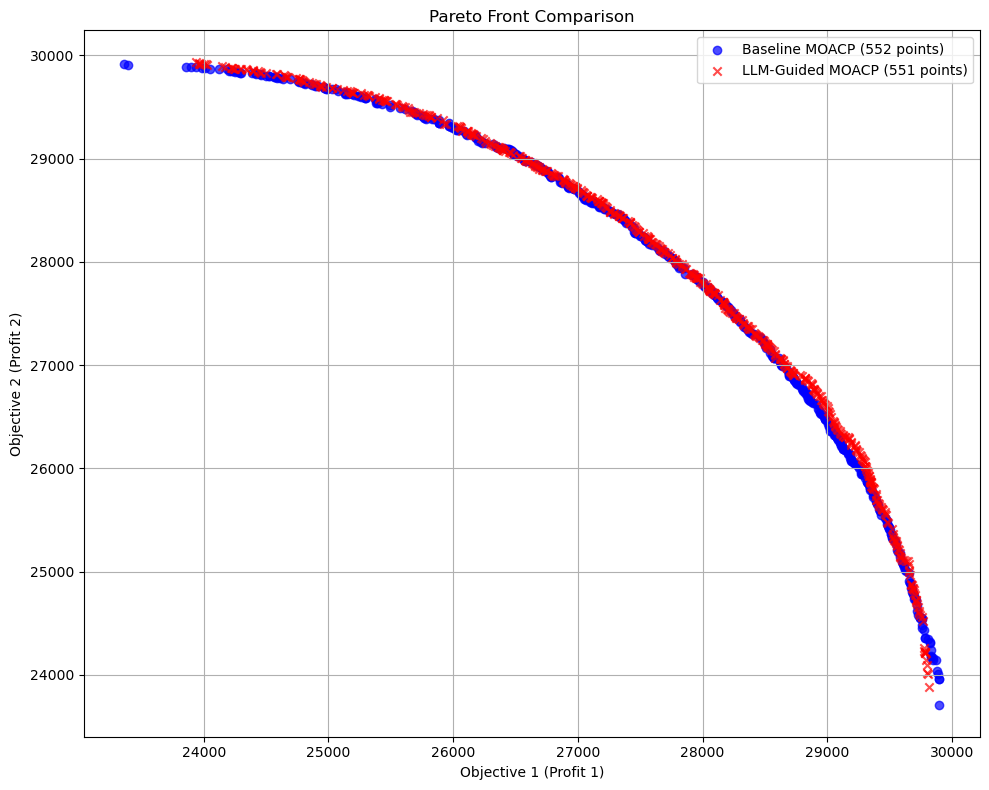

In [26]:
# Call the function with your file names and descriptive titles
plot_comparison_pareto(
    filename1="7502_ResultsMD.txt",
    filename2="7502_Results_Perturbation2nd.txt",
    title1="Baseline MOACP",
    title2="LLM-Guided MOACP"
)